# Bank Marketing Campaign — Prediksi Deposito Nasabah
### Capstone Project Module 2 — Klasifikasi
Salomo Agus Ardianto Purba

---

## Business Problem Understanding

### Context
Sebuah bank yang menjalankan kampanye telemarketing untuk menawarkan produk **term deposit** (deposito berjangka) kepada nasabahnya. Kampanye ini dilakukan melalui panggilan telepon langsung oleh agen marketing. Namun, tidak semua nasabah yang dihubungi akhirnya melakukan deposit — sehingga banyak sumber daya (waktu agen, biaya telepon) yang terbuang untuk menghubungi nasabah yang tidak berminat.

**Target:**
- `yes` → Nasabah melakukan deposito (kelas positif)
- `no`  → Nasabah tidak melakukan deposito (kelas negatif)

---

### Problem Statement
Proses telemarketing yang tidak tersegmentasi menyebabkan inefisiensi biaya dan waktu yang signifikan. Bank menghubungi seluruh nasabah tanpa filter, sehingga banyak kontak yang sia-sia kepada nasabah yang tidak berminat melakukan deposito. Hal ini berpotensi membuang hingga **>50% anggaran** kampanye pada prospek yang tidak relevan.

### Goals
Membangun model klasifikasi yang mampu **memprediksi kemungkinan seorang nasabah akan melakukan deposito**, sehingga tim marketing dapat:
1. Memprioritaskan nasabah dengan probabilitas tinggi untuk melakukan deposito
2. Mengurangi biaya kampanye secara terukur 
3. Meningkatkan conversion rate per kontak yang dilakukan

### Analytic Approach
Analisis ini akan menggunakan pendekatan **supervised machine learning klasifikasi binary** untuk memprediksi apakah nasabah akan melakukan deposito (`yes`/`no`) berdasarkan fitur demografis, finansial, dan riwayat kontak.

### Metric Evaluation

**Tipe Error dan Konsekuensinya:**

| Error | Penjelasan | Konsekuensi Bisnis |
|---|---|---|
| **False Positive (FP)** | Diprediksi deposit, ternyata tidak | Biaya kontak terbuang (waktu agen, telepon) |
| **False Negative (FN)** | Diprediksi tidak deposit, ternyata ya | Kehilangan nasabah potensial = kehilangan revenue |

Kedua jenis error sama-sama memiliki dampak bisnis. Oleh karena itu, metric utama yang digunakan adalah **ROC-AUC**, karena:
- Mengukur kemampuan model membedakan dua kelas secara keseluruhan
- Tidak terpengaruh threshold — cocok untuk dataset yang hampir seimbang
- Mencerminkan trade-off FPR vs TPR yang relevan dengan konteks bisnis

Sebagai metric pendukung digunakan **Precision, Recall, dan F1-Score** per kelas.


### Attribute Information

| Kolom | Tipe | Deskripsi |
|---|---|---|
| `age` | Numerik | Usia nasabah (tahun) |
| `job` | Kategorik | Jenis pekerjaan nasabah |
| `balance` | Numerik | Saldo rata-rata rekening (EUR) |
| `housing` | Kategorik | Apakah memiliki KPR (yes/no) |
| `loan` | Kategorik | Apakah memiliki pinjaman pribadi (yes/no) |
| `contact` | Kategorik | Jenis media kontak (cellular/telephone/unknown) |
| `month` | Kategorik | Bulan terakhir dihubungi |
| `campaign` | Numerik | Jumlah kontak dalam kampanye ini |
| `pdays` | Numerik | Hari sejak kontak kampanye sebelumnya (-1 = belum pernah) |
| `poutcome` | Kategorik | Hasil kampanye sebelumnya |
| `deposit` | Kategorik | **TARGET** — apakah nasabah melakukan deposito (yes/no) |

> **Catatan:** `pdays = -1` berarti nasabah **belum pernah dihubungi** sebelumnya.

### Import Library

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Preprocessing & Modeling
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     cross_val_score, GridSearchCV)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
import lightgbm as lgb

# Evaluation
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             f1_score, precision_score, recall_score, accuracy_score)

# Imbalance
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

# Save model
import pickle


## 1. Data Loading & Understanding

In [11]:
df = pd.read_csv("Data/data_bank_marketing_campaign.csv")
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (7813, 11)


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


In [12]:
# Info & Missing Values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       7813 non-null   int64
 1   job       7813 non-null   str  
 2   balance   7813 non-null   int64
 3   housing   7813 non-null   str  
 4   loan      7813 non-null   str  
 5   contact   7813 non-null   str  
 6   month     7813 non-null   str  
 7   campaign  7813 non-null   int64
 8   pdays     7813 non-null   int64
 9   poutcome  7813 non-null   str  
 10  deposit   7813 non-null   str  
dtypes: int64(4), str(7)
memory usage: 671.6 KB


In [16]:
list_item = []
for col in df.columns:
    list_item.append([
        col, df[col].dtype,
        df[col].isna().sum(),
        round(df[col].isna().sum() / len(df) * 100, 2),
        df[col].nunique(),
        list(df[col].value_counts().head(3).index)
    ])

dfDesc = pd.DataFrame(list_item,
    columns=['Feature','Dtype','Null','Null%','Unique','Top3_Values'])
dfDesc

,Feature,Dtype,Null,Null%,Unique,Top3_Values
0,age,int64,0,0.0,75,"[31, 32, 30]"
1,job,str,0,0.0,12,"[management, blue-collar, technician]"
2,balance,int64,0,0.0,3153,"[0, 1, 3]"
3,housing,str,0,0.0,2,"[no, yes]"
4,loan,str,0,0.0,2,"[no, yes]"
5,contact,str,0,0.0,3,"[cellular, unknown, telephone]"
6,month,str,0,0.0,12,"[may, aug, jul]"
7,campaign,int64,0,0.0,32,"[1, 2, 3]"
8,pdays,int64,0,0.0,422,"[-1, 92, 91]"
9,poutcome,str,0,0.0,4,"[unknown, failure, success]"


## 2. Exploratory Data Analysis (EDA)

### 2.1 Target Distribution

Distribusi Target (deposit):
deposit
no     4081
yes    3732
Name: count, dtype: int64

Proporsi (%):
deposit
no     52.23
yes    47.77
Name: proportion, dtype: float64


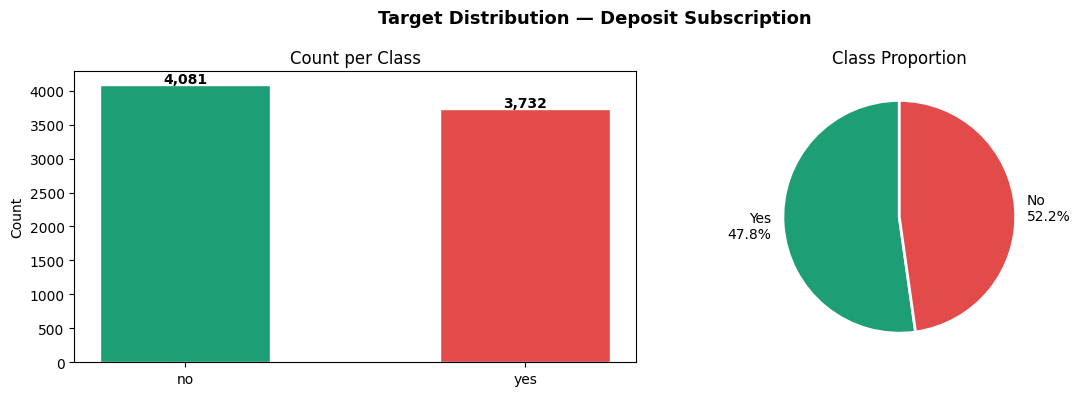

In [17]:
print("Distribusi Target (deposit):")
print(df['deposit'].value_counts())
print()
print("Proporsi (%):")
print(df['deposit'].value_counts(normalize=True).mul(100).round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Target Distribution — Deposit Subscription', fontsize=13, fontweight='bold')

counts = df['deposit'].value_counts()
colors = ['#1D9E75', '#E24B4A']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_title('Count per Class')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{val:,}', ha='center', fontweight='bold')

pct = df['deposit'].value_counts(normalize=True) * 100
axes[1].pie(pct.values,
            labels=[f'Yes\n{pct["yes"]:.1f}%', f'No\n{pct["no"]:.1f}%'],
            colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Proportion')
plt.tight_layout()
plt.show()

**Insight:** Dataset relatif **seimbang** — 47.8% yes vs 52.2% no. Meski demikian, kita tetap akan menguji pengaruh oversampling pada performa model.

### 2.2 Numerical Features vs Target

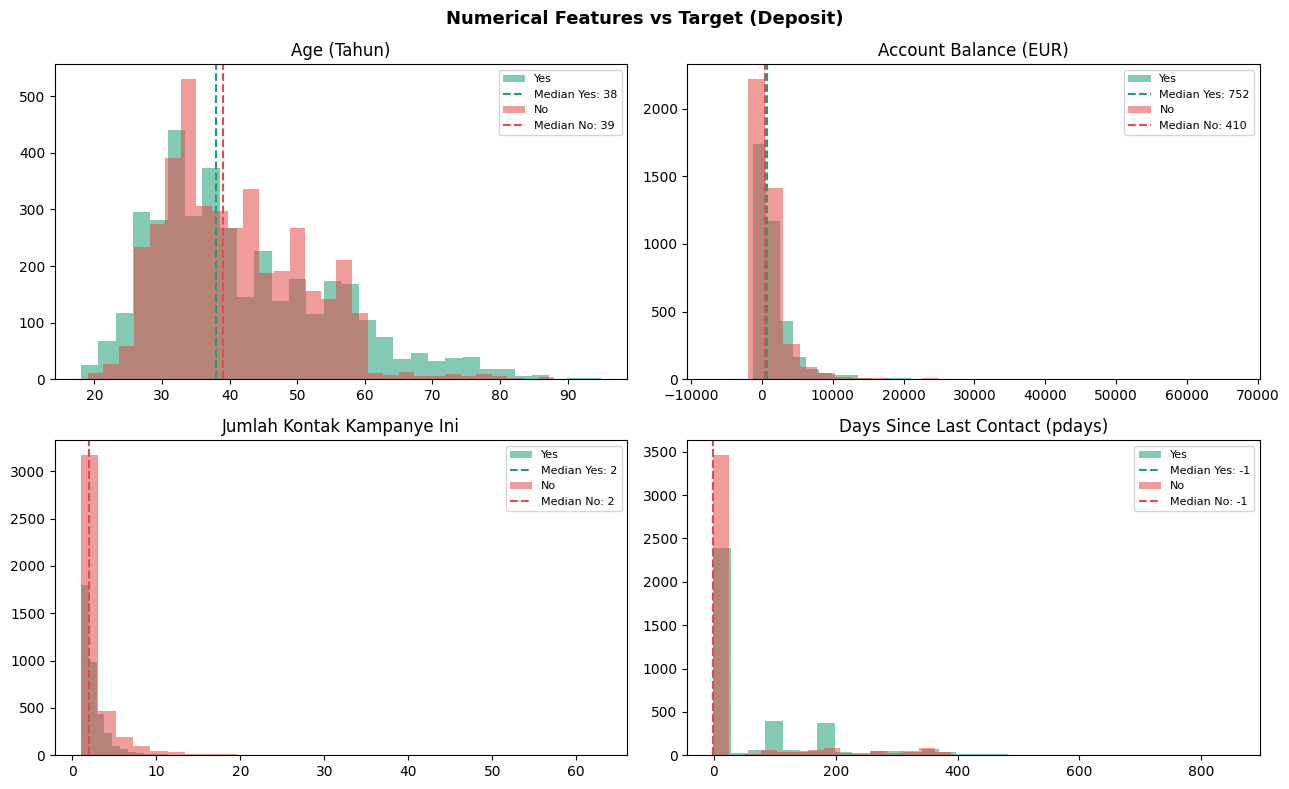

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Numerical Features vs Target (Deposit)', fontsize=13, fontweight='bold')

num_info = [
    ('age', 'Age (Tahun)'),
    ('balance', 'Account Balance (EUR)'),
    ('campaign', 'Jumlah Kontak Kampanye Ini'),
    ('pdays', 'Days Since Last Contact (pdays)')
]

for ax, (col, title) in zip(axes.flatten(), num_info):
    for val, color, label in [('yes', '#1D9E75', 'Yes'), ('no', '#E24B4A', 'No')]:
        data = df[df['deposit'] == val][col]
        ax.hist(data, bins=30, alpha=0.55, color=color, label=label, edgecolor='none')
        ax.axvline(data.median(), color=color, linestyle='--', linewidth=1.5,
                   label=f'Median {label}: {data.median():.0f}')
    ax.set_title(title)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Insight Numerical Features:**
- **Age:** Nasabah yang lebih tua (>60 tahun) dan lebih muda (<30 tahun) cenderung lebih banyak yang deposit
- **Balance:** Nasabah dengan saldo lebih tinggi cenderung lebih banyak melakukan deposit
- **Campaign:** Nasabah yang dihubungi terlalu sering (>5x) justru lebih sedikit yang deposit — diminishing returns
- **Pdays:** Nasabah yang sudah pernah dihubungi sebelumnya (pdays ≠ -1) memiliki kecenderungan lebih tinggi untuk deposit

### 2.3 Categorical Features vs Target

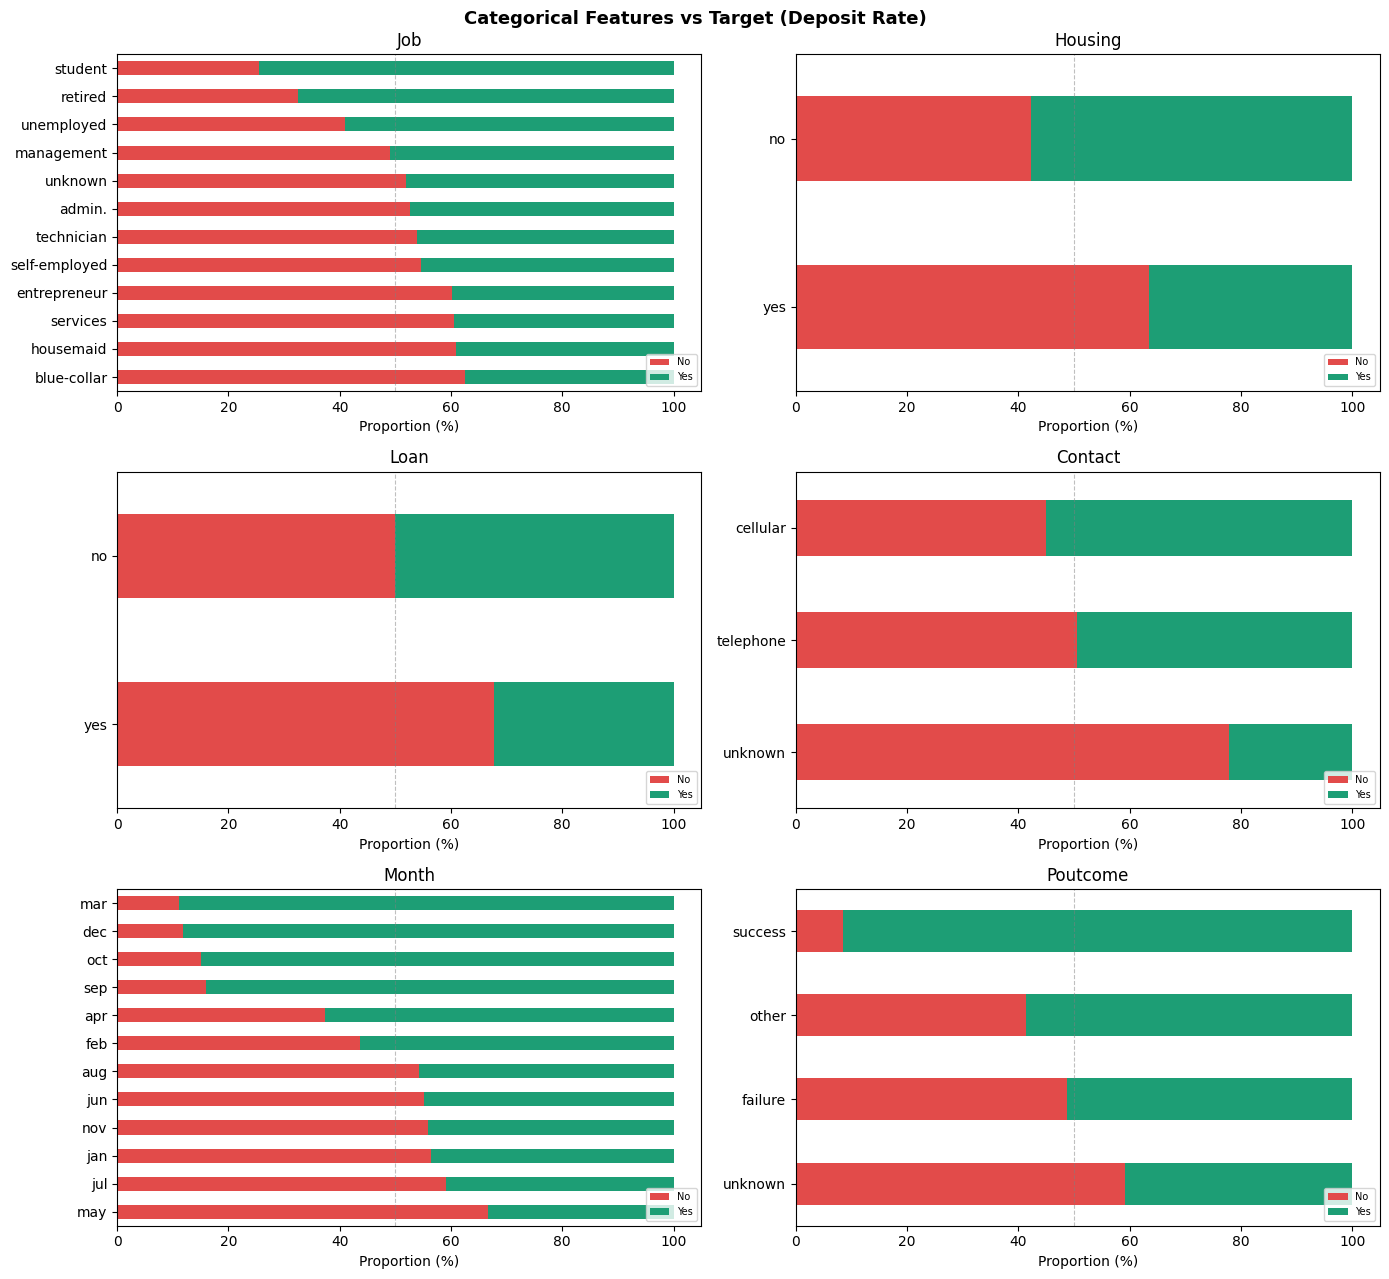

In [19]:
cat_cols_plot = ['job', 'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 2, figsize=(14, 13))
fig.suptitle('Categorical Features vs Target (Deposit Rate)', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flatten(), cat_cols_plot):
    ct = pd.crosstab(df[col], df['deposit'], normalize='index') * 100
    ct = ct.sort_values('yes', ascending=True)
    ct[['no', 'yes']].plot(kind='barh', stacked=True, ax=ax,
                            color=['#E24B4A', '#1D9E75'], edgecolor='none')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Proportion (%)')
    ax.set_ylabel('')
    ax.legend(['No', 'Yes'], loc='lower right', fontsize=7)
    ax.axvline(50, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

**Insight Categorical Features:**
- **Job:** `student` dan `retired` memiliki deposit rate tertinggi; `blue-collar` terendah
- **Housing:** Nasabah tanpa KPR lebih cenderung deposit
- **Loan:** Nasabah tanpa pinjaman pribadi lebih cenderung deposit
- **Contact:** Kontak via `cellular` lebih efektif dibanding `telephone` atau `unknown`
- **Month:** Bulan `mar`, `sep`, `oct`, `dec` memiliki deposit rate tertinggi; `may` memiliki volume terbanyak tapi conversion rate rendah
- **Poutcome:** `success` (kampanye sebelumnya berhasil) = predictor terkuat untuk deposit

## 3. Data Cleaning

In [21]:
# Cek duplikat
print(f"Jumlah data duplikat: {df.duplicated().sum()}")
df = df.drop_duplicates()
print(f"Shape setelah hapus duplikat: {df.shape}")

Jumlah data duplikat: 8
Shape setelah hapus duplikat: (7805, 11)


In [22]:
# Cek outlier dengan IQR method
print("=== Outlier Check (IQR Method) ===")
for col in ['age', 'balance', 'campaign', 'pdays']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"{col:12s}: {n_out:4d} outliers ({n_out/len(df)*100:.1f}%) "
          f"| range [{df[col].min():.0f}, {df[col].max():.0f}]")

=== Outlier Check (IQR Method) ===
age         :  121 outliers (1.6%) | range [18, 95]
balance     :  736 outliers (9.4%) | range [-6847, 66653]
campaign    :  429 outliers (5.5%) | range [1, 63]
pdays       : 1432 outliers (18.3%) | range [-1, 854]


**Keputusan Handling Outlier:**
- **balance:** Outlier ada namun mencerminkan data nyata (nasabah kaya vs miskin) → **dipertahankan**. LightGBM tree-based sehingga robust terhadap outlier.
- **campaign:** Nilai ekstrim (max=63) mungkin noise, namun fitur ini tetap informatif → **dipertahankan**, akan di-log-transform pada feature engineering.
- **pdays:** Nilai -1 bukan outlier — ini adalah encoding khusus "belum pernah dihubungi" → akan dibuat fitur biner baru.
- **age:** Outlier (>75 tahun) valid secara bisnis → **dipertahankan**.

Dataset sudah **tidak memiliki missing values**. Tidak diperlukan imputasi pada data mentah.

## 4. Feature Engineering

In [58]:
# Feature Engineering
# 1. pdays_contacted: binary flag apakah nasabah pernah dihubungi sebelumnya
df['pdays_contacted'] = (df['pdays'] != -1).astype(int)

# 2. balance_neg: flag rekening dengan saldo negatif
df['balance_neg'] = (df['balance'] < 0).astype(int)

# 3. campaign_log: log-transform untuk meredam outlier campaign
df['campaign_log'] = np.log1p(df['campaign'])

# 4. month_num: konversi bulan ke angka untuk relasi temporal
month_order = {'jan':1,'feb':2,'mar':3,'apr':4,'may':5,'jun':6,
               'jul':7,'aug':8,'sep':9,'oct':10,'nov':11,'dec':12}
df['month_num'] = df['month'].map(month_order)


# Target encoding
df['target'] = (df['deposit'] == 'yes').astype(int)

print("Fitur baru yang ditambahkan:")
new_feats = ['pdays_contacted', 'balance_neg', 'campaign_log', 'month_num']
for f in new_feats:
    print(f"  • {f}: {df[f].describe().to_dict()}")

Fitur baru yang ditambahkan:
  • pdays_contacted: {'count': 7805.0, 'mean': 0.2557335041639974, 'std': 0.43630066271327356, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 1.0, 'max': 1.0}
  • balance_neg: {'count': 7805.0, 'mean': 0.06137091607943626, 'std': 0.24002480736249773, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 1.0}
  • campaign_log: {'count': 7805.0, 'mean': 1.110382211261553, 'std': 0.4831788957810877, 'min': 0.6931471805599453, '25%': 0.6931471805599453, '50%': 1.0986122886681098, '75%': 1.3862943611198906, 'max': 4.1588830833596715}
  • month_num: {'count': 7805.0, 'mean': 6.194618834080718, 'std': 2.5580240782504764, 'min': 1.0, '25%': 5.0, '50%': 6.0, '75%': 8.0, 'max': 12.0}


In [60]:
# Korelasi fitur numerik dengan target
df_num = df[['age','balance','campaign','pdays','pdays_contacted',
             'balance_neg','campaign_log','month_num','target']]
corr = df_num.corr()['target'].sort_values(ascending=False)
print("Korelasi fitur dengan target:")
print(corr.drop('target'))

Korelasi fitur dengan target:
pdays_contacted    0.238178
pdays              0.157817
balance            0.092403
age                0.046417
month_num          0.029188
balance_neg       -0.095021
campaign          -0.133766
campaign_log      -0.141149
Name: target, dtype: float64


## 5. Preprocessing Pipeline

In [61]:
cat_cols = ['job', 'housing', 'loan', 'contact', 'poutcome']
num_cols = ['age', 'balance', 'campaign', 'pdays',
            'pdays_contacted', 'balance_neg', 'campaign_log', 'month_num']

X = df[cat_cols + num_cols]
y = df['target']

# Transformers
cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
num_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
transformer = ColumnTransformer([
    ('cat', cat_transformer, cat_cols),
    ('num', num_transformer, num_cols)
])

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Train target dist: {y_train.value_counts().to_dict()}")
print(f"Test  target dist: {y_test.value_counts().to_dict()}")

X_train: (6244, 13) | X_test: (1561, 13)
Train target dist: {0: 3260, 1: 2984}
Test  target dist: {0: 815, 1: 746}


## 6. Modeling & Evaluation

### 6.1 Model Benchmarking — 5-Fold CV

In [70]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0),
    'LightGBM': lgb.LGBMClassifier(random_state=42, verbosity=-1)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    pipe = Pipeline([('prep', transformer), ('model', model)])
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=skf, scoring='roc_auc')
    results.append({'Model': name, 'Mean ROC-AUC': round(cv_scores.mean(), 4),
                    'Std': round(cv_scores.std(), 4)})

res_df = pd.DataFrame(results).sort_values('Mean ROC-AUC', ascending=False)
print(res_df.to_string(index=False))

              Model  Mean ROC-AUC    Std
           LightGBM        0.7686 0.0104
            XGBoost        0.7562 0.0139
      Random Forest        0.7537 0.0116
Logistic Regression        0.7312 0.0088
                KNN        0.7075 0.0137
      Decision Tree        0.6278 0.0116


### 6.2 Test Oversampling dengan 10-Fold CV

In [72]:
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
lgbm_params = dict(num_leaves=21, learning_rate=0.05, num_iterations=75,
                   min_data_in_leaf=30, random_state=42, verbosity=-1)

train_no_os, val_no_os = [], []
train_os, val_os = [], []

for tr_idx, val_idx in kf.split(X_train, y_train):
    X_tr, X_v = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_v = y_train.iloc[tr_idx], y_train.iloc[val_idx]

    # Without oversampling
    pipe1 = Pipeline([('prep', transformer), ('model', lgb.LGBMClassifier(**lgbm_params))])
    pipe1.fit(X_tr, y_tr)
    train_no_os.append(roc_auc_score(y_tr, pipe1.predict_proba(X_tr)[:,1]))
    val_no_os.append(roc_auc_score(y_v, pipe1.predict_proba(X_v)[:,1]))

    # With oversampling
    ros = RandomOverSampler(random_state=42)
    X_ros, y_ros = ros.fit_resample(X_tr, y_tr)
    pipe2 = Pipeline([('prep', transformer), ('model', lgb.LGBMClassifier(**lgbm_params))])
    pipe2.fit(X_ros, y_ros)
    train_os.append(roc_auc_score(y_ros, pipe2.predict_proba(X_ros)[:,1]))
    val_os.append(roc_auc_score(y_v, pipe2.predict_proba(X_v)[:,1]))

print("=== Without Oversampling ===")
print(f"Train ROC-AUC: {np.mean(train_no_os):.4f} ± {np.std(train_no_os):.4f}")
print(f"Val   ROC-AUC: {np.mean(val_no_os):.4f} ± {np.std(val_no_os):.4f}")
print("\n=== With Oversampling ===")
print(f"Train ROC-AUC: {np.mean(train_os):.4f} ± {np.std(train_os):.4f}")
print(f"Val   ROC-AUC: {np.mean(val_os):.4f} ± {np.std(val_os):.4f}")


=== Without Oversampling ===
Train ROC-AUC: 0.8267 ± 0.0017
Val   ROC-AUC: 0.7775 ± 0.0242

=== With Oversampling ===
Train ROC-AUC: 0.8282 ± 0.0022
Val   ROC-AUC: 0.7779 ± 0.0233


### 6.3 Hyperparameter Tuning — GridSearchCV

In [73]:
ros = RandomOverSampler(random_state=42)
lgbm = lgb.LGBMClassifier(random_state=42, verbosity=-1)

best_pipe = ImbPipeline([
    ('oversampling', ros),
    ('prep', transformer),
    ('model', lgbm)
])

param_grid = [{
    'model__num_leaves': [21, 31, 41],
    'model__learning_rate': [0.05, 0.1, 0.15],
    'model__num_iterations': [75, 100, 125],
    'model__min_data_in_leaf': [20, 30],
}]

grid = GridSearchCV(best_pipe, param_grid, scoring='roc_auc',
                    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
                    n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print("Best hyperparameters:", grid.best_params_)
print(f"Best CV ROC-AUC: {grid.best_score_:.4f}")

best_model = grid.best_estimator_

Best hyperparameters: {'model__learning_rate': 0.05, 'model__min_data_in_leaf': 30, 'model__num_iterations': 75, 'model__num_leaves': 21}
Best CV ROC-AUC: 0.7779


### 6.4 Evaluasi Final Model pada Test Data

In [55]:
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Deposit', 'Yes Deposit']))

Test ROC-AUC: 0.7880

Classification Report:
              precision    recall  f1-score   support

  No Deposit       0.71      0.83      0.76       815
 Yes Deposit       0.77      0.63      0.69       746

    accuracy                           0.73      1561
   macro avg       0.74      0.73      0.73      1561
weighted avg       0.74      0.73      0.73      1561



### 6.5 Feature Importance

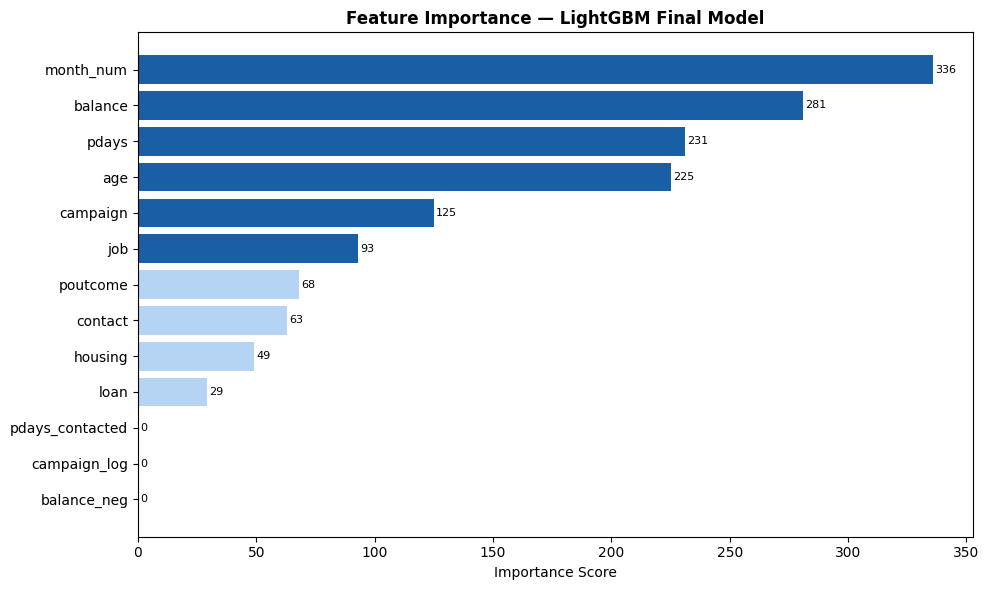


Top 5 fitur paling penting:
  Feature  Importance
month_num         336
  balance         281
    pdays         231
      age         225
 campaign         125


In [75]:
lgbm_model = best_model.named_steps['model']
feat_names = cat_cols + num_cols
importances = lgbm_model.feature_importances_

feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

colors = ['#185FA5' if imp > feat_df['Importance'].median() else '#B5D4F4'
          for imp in feat_df['Importance']]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=colors, edgecolor='none')
ax.set_title('Feature Importance — LightGBM Final Model', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, feat_df['Importance']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
            f'{val}', va='center', fontsize=8)
plt.tight_layout()
plt.show()
print("\nTop 5 fitur paling penting:")
print(feat_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

### 6.6 Limitasi Model — Kapan Model Dapat & Tidak Dapat Dipercaya

#### Kondisi Model Dapat Dipercaya
1. **Nasabah yang sudah pernah dihubungi sebelumnya (`pdays ≠ -1`)** — model sangat baik memprediksi kelompok ini karena ada riwayat respons
2. **Profil umum:** Nasabah usia 25–60 tahun, saldo positif, pekerjaan management/technician/admin — kelompok ini mendominasi training data
3. **Bulan kampanye:** Mar, Sep, Oct, Dec — pola seasonal ini tercermin baik di training data
4. **Nasabah dengan poutcome = 'success'** — predictor terkuat, model sangat akurat untuk kelompok ini

#### Kondisi Model Kurang Dapat Dipercaya
1. **Nasabah dengan profil sangat langka** di training data: poutcome = other, pekerjaan housemaid/unknown, usia >80 tahun
2. **Nasabah yang belum pernah dihubungi sebelumnya + contact = unknown** — informasi sangat terbatas
3. **Bulan yang tidak ada di training data** (jika kampanye dilakukan pada bulan yang tidak ada dalam dataset)
4. **Saldo sangat ekstrim** (>50.000 EUR atau sangat negatif) — data sangat sedikit di range ini
5. **Model tidak mempertimbangkan kondisi ekonomi makro** — perubahan suku bunga atau kondisi pasar dapat menggeser perilaku nasabah secara fundamental


## 7. Conclusion & Recommendation

### Kesimpulan

Model **LightGBM** dengan hyperparameter yang telah di-tuning dan teknik oversampling (RandomOverSampler) berhasil dibangun sebagai solusi prediksi nasabah yang akan melakukan deposito.

**Performa final model pada test set:**

| Metric | Nilai |
|---|---|
| ROC-AUC | **0.7812** |
| Accuracy | **0.73** |
| Precision (Yes) | **0.75** |
| Recall (Yes) | **0.65** |
| F1-Score (Yes) | **0.70** |

**Interpretasi bisnis dari classification report:**
- Model dapat **mengidentifikasi 65% nasabah yang benar-benar akan deposit** (Recall = 0.65)
- Dari nasabah yang diprediksi akan deposit, **75% prediksi benar** (Precision = 0.75)
- **False Positive (kontak sia-sia):** 165 dari 815 nasabah tidak deposit (20.2%)

---

### Simulasi Dampak Bisnis

Asumsi: 1 kontak telemarketing = Rp 50.000 (biaya agen + telepon), per 1.000 nasabah (480 potensial deposit)

| Skenario | Total Kontak | Deposit Tertangkap | Biaya | Penghematan |
|---|---|---|---|---|
| Tanpa model (hubungi semua) | 1.000 orang | 480 orang (100%) | Rp 50.000.000 | — |
| **Dengan model** | **417 orang** | **311 orang (64.8%)** | **Rp 20.850.000** | **Rp 29.150.000** |

> Dengan model, bank dapat **menghemat 58% biaya kampanye** dengan hanya melepas 35% nasabah potensial.


## 8. Save Model 

In [79]:
import pickle

with open('capstone_2.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Model berhasil disimpan sebagai 'capstone_2.pkl'")

# Verifikasi load ulang
with open('capstone_2.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

y_pred_verify = loaded_model.predict(X_test)
print(f"Verifikasi: ROC-AUC dari loaded model = {roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:,1]):.4f}")
print("✓ Model berhasil di-load dan berjalan dengan baik!")

Model berhasil disimpan sebagai 'capstone_2.pkl'
Verifikasi: ROC-AUC dari loaded model = 0.7812
✓ Model berhasil di-load dan berjalan dengan baik!
